25 / 167
50 / 167
75 / 167
100 / 167
125 / 167
150 / 167
167 documentos cargados.
121 de 167 documentos con fecha


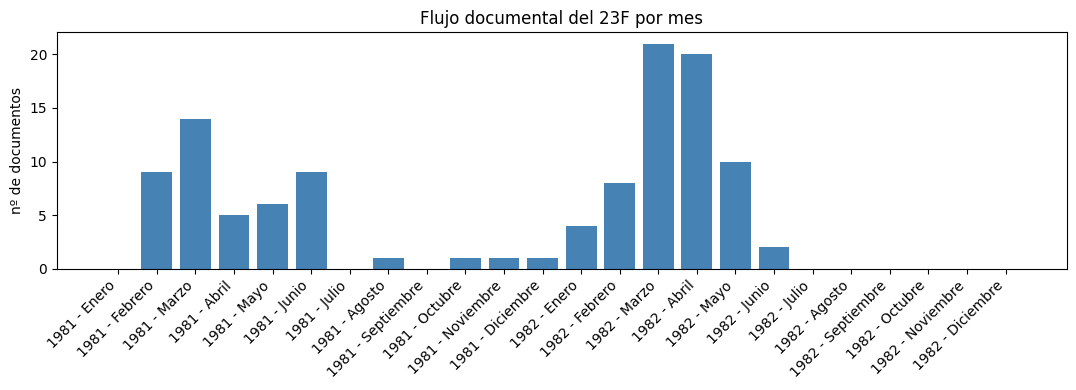


Media: 4.7 documentos/mes
Meses atipicos:
  1982 - Marzo: 21 documentos (pico, z=+2.6)
  1982 - Abril: 20 documentos (pico, z=+2.4)
Tema 0: coronel, congreso, armada, capitán, teniente, tejero, civil, guardia
Tema 1: antonio, allí, carmen, llamada, luego, visto, teléfono, llamado
Tema 2: gobierno, españa, golpe, militares, situación, febrero, parte, acción
Tema 3: civil, guardia, madrid, coronel, teniente, horas, sección, diputados
Tema 4: justicia, excmo, defensa, años, consejo, teniente, supremo, tribunal


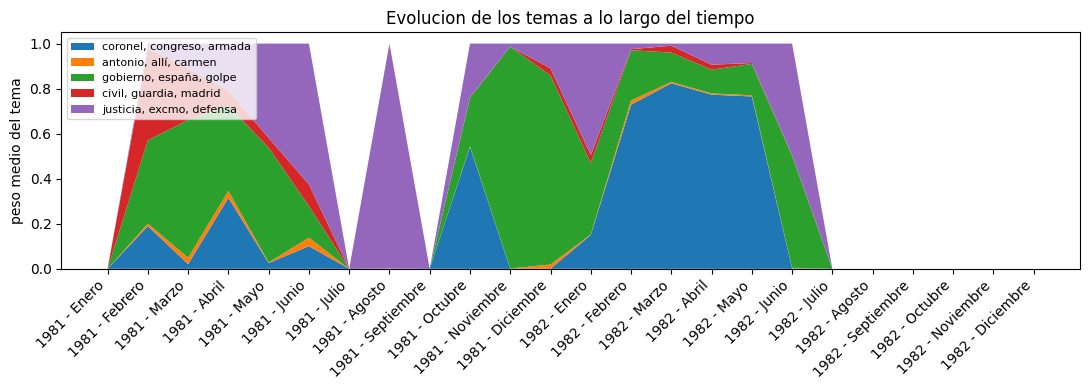

In [ ]:
# 0.1  imports y configuracion
import os, re, time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

OUTPUTS_DIR = Path("outputs")
OUTPUTS_DIR.mkdir(exist_ok=True)

BASE = "https://23fbuscador.rtve.es"

# 0.2  funcion que extrae los datos de un documento
def extraer(url):
    sopa = BeautifulSoup(requests.get(url, timeout=30).text, "lxml")
    meta = {}
    for div in sopa.select(".detail-grid div"):
        texto = div.get_text(strip=True)
        if ":" in texto:
            clave, valor = texto.split(":", 1)
            meta[clave.strip().lower()] = valor.strip()
    resumen = sopa.select_one("p.text-box")
    transcripcion = sopa.select_one("pre.text-box-large")
    return {
        "id": int(url.split("/")[-1]),
        "titulo": sopa.select_one("header.page-header h2").get_text(strip=True),
        "detalle_url": url,
        "original_url": url + "/original",
        "tipo": meta.get("tipo"),
        "estado": meta.get("estado"),
        "paginas": meta.get("páginas"),
        "kb": meta.get("kb"),
        "modelo_ocr": meta.get("modelo"),
        "proveedor_ocr": meta.get("proveedor"),
        "resumen": resumen.get_text(strip=True) if resumen else "",
        "personas": " | ".join(c.get_text(strip=True) for c in sopa.select(".tag-group-people .tag-chip")),
        "lugares": " | ".join(c.get_text(strip=True) for c in sopa.select(".tag-group-places .tag-chip")),
        "palabras_clave": " | ".join(c.get_text(strip=True) for c in sopa.select(".tag-group-keywords .tag-chip")),
        "texto_completo": transcripcion.get_text() if transcripcion else "",
    }

# 0.3  descargar todos los documentos del Buscador 23F
listado = BeautifulSoup(requests.get(BASE + "/?page_size=200", timeout=30).text, "lxml")
urls = [BASE + a["href"].split("?")[0] for a in listado.select("a.link-button")]
documentos = []
for i, url in enumerate(urls, 1):
    documentos.append(extraer(url))
    time.sleep(0.4)
    if i % 25 == 0:
        print(i, "/", len(urls))

# 0.4  guardar el dataset y dejarlo listo para el resto del notebook
df = pd.DataFrame(documentos)
os.makedirs("data", exist_ok=True)
df.to_csv("data/documentos_23f.csv", index=False, encoding="utf-8-sig")
print(len(df), "documentos cargados.")

# 1.1  extraer la fecha de cada documento
MESES = {"enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,
         "julio":7,"agosto":8,"septiembre":9,"octubre":10,"noviembre":11,"diciembre":12}
NOMBRE_MES = {n: m.capitalize() for m, n in MESES.items()}

def etiqueta(ts):
    return f"{ts.year} - {NOMBRE_MES[ts.month]}"

def buscar_fecha(texto):
    m = re.search(r"(\d{1,2}) de (\w+) de (\d{4})", str(texto).lower())
    if m and m.group(2) in MESES:
        try:
            return pd.Timestamp(int(m.group(3)), MESES[m.group(2)], int(m.group(1)))
        except ValueError:
            return None
    return None

df["fecha"] = df["titulo"].apply(buscar_fecha)
sin_fecha = df["fecha"].isna()
df.loc[sin_fecha, "fecha"] = df.loc[sin_fecha, "texto_completo"].apply(buscar_fecha)
print(df["fecha"].notna().sum(), "de", len(df), "documentos con fecha")

# 1.2  construir la serie temporal (documentos por mes, ventana 1981-1982)
fechados = df.dropna(subset=["fecha"]).copy()
serie = fechados.set_index("fecha").resample("ME").size()
serie = serie["1981-01":"1982-12"]

# 1.3  visualizar el flujo documental
plt.figure(figsize=(11, 4))
plt.bar([etiqueta(t) for t in serie.index], serie.values, color="steelblue")
plt.title("Flujo documental del 23F por mes")
plt.ylabel("nº de documentos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "caso1_serie_temporal.png", dpi=150)
plt.show()

# 1.4  detectar meses atipicos con el z-score
media, desv = serie.mean(), serie.std()
zscore = (serie - media) / desv
atipicos = serie[zscore.abs() > 1.5]
print(f"\nMedia: {media:.1f} documentos/mes")
print("Meses atipicos:")
for fecha, n in atipicos.items():
    nombre = "pico" if n > media else "valle"
    print(f"  {etiqueta(fecha)}: {n} documentos ({nombre}, z={zscore[fecha]:+.1f})")

# 1.5  topic modelling con LDA
EXTRA = ["bueno","pues","dicho","ahora","aqui","aquí","bien","entonces","puede","pueden",
         "decir","hacer","ser","sido","tan","asi","así","cada","tras","solo","sólo","señor",
         "usted","ustedes","entiendo","creo","verdad","cosa","cosas","hablar","spain",
         "jpeg","jpg","png","ocr","documento","documentos","pagina","páginas","folio"]
stop_es = stopwords.words("spanish") + EXTRA
N_TEMAS = 5

vec = CountVectorizer(stop_words=stop_es, min_df=4, max_df=0.6,
                      token_pattern=r"[a-záéíóúñ]{4,}")
X = vec.fit_transform(df["texto_completo"].fillna("").astype(str))

lda = LatentDirichletAllocation(n_components=N_TEMAS, max_iter=25, random_state=0)
doc_temas = lda.fit_transform(X)

palabras = vec.get_feature_names_out()
nombres = []
for k, comp in enumerate(lda.components_):
    top = [palabras[i] for i in comp.argsort()[-8:][::-1]]
    nombres.append(", ".join(top[:3]))
    print(f"Tema {k}: {', '.join(top)}")

# 1.6  evolucion de los temas a lo largo del tiempo
for k in range(N_TEMAS):
    df[f"tema_{k}"] = doc_temas[:, k]

cols = [f"tema_{k}" for k in range(N_TEMAS)]
evol = df.dropna(subset=["fecha"]).set_index("fecha")[cols].resample("ME").mean()
evol = evol["1981-01":"1982-12"].fillna(0)

plt.figure(figsize=(11, 4))
plt.stackplot([etiqueta(t) for t in evol.index], evol.T.values, labels=nombres)
plt.title("Evolucion de los temas a lo largo del tiempo")
plt.ylabel("peso medio del tema")
plt.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "caso1_temas_tiempo.png", dpi=150)
plt.show()

tipo_doc
Otros                   75
Vista oral              46
Comunicacion oficial    24
Informe                 12
Nota                    10
Name: count, dtype: int64
Baseline         solo texto=0.124   con variables propias=0.124
Naive Bayes      solo texto=0.496   con variables propias=0.449
Reg. logistica   solo texto=0.652   con variables propias=0.719
SVM lineal       solo texto=0.632   con variables propias=0.653
Random Forest    solo texto=0.509   con variables propias=0.526
F1-macro del mejor modelo: 0.732


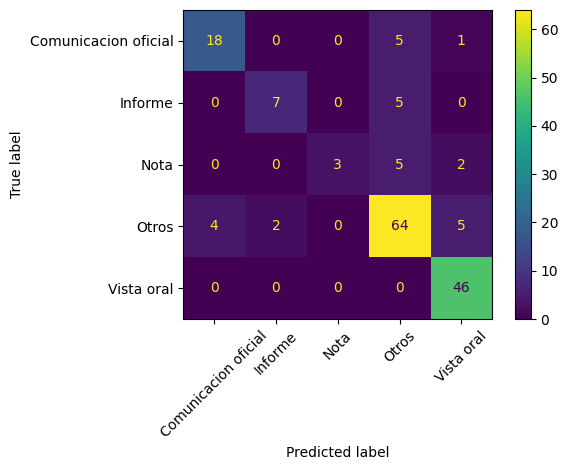

29 de 167 documentos mal clasificados
                                                                                                                                      titulo             tipo_doc           prediccion
                                                                                                 Información integrada (17 de mayo de 1982).              Informe                Otros
                                                                                       Relato de los sucesos de los días 23 y 24 de febrero.                Otros           Vista oral
                         Comentarios sobre la sentencia del 23-F. Cuartel general de la Junta de Jefes de Estado Mayor (6 de junio de 1982).                Otros Comunicacion oficial
Nota al PREJUJEM (Presidente de la Junta de Jefes de Estado Mayor). Algunos datos para una crónica de un golpe anunciado (Jesús M. Paricio).                 Nota                Otros
                                      Informe s

In [ ]:
# 2.1  imports y construccion del target (tipo de documento) desde el titulo
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
from scipy.sparse import hstack

def tipo_documento(titulo):
    t = str(titulo).lower()
    if "vista oral" in t:
        return "Vista oral"
    if "informe" in t or "información integrada" in t:
        return "Informe"
    if t.startswith("nota") or "nota informativa" in t:
        return "Nota"
    if "reservado" in t or "secreto" in t or "oficio" in t or "telegrama" in t:
        return "Comunicacion oficial"
    return "Otros"

df["tipo_doc"] = df["titulo"].apply(tipo_documento)
print(df["tipo_doc"].value_counts())

# 2.2  feature engineering: TF-IDF del texto + variables propias
tfidf = TfidfVectorizer(stop_words=stopwords.words("spanish"), min_df=4, max_df=0.6,
                        ngram_range=(1, 2), token_pattern=r"[a-záéíóúñ]{4,}")
X_texto = tfidf.fit_transform(df["texto_completo"].fillna("").astype(str))

extra = pd.DataFrame({
    "longitud": df["texto_completo"].fillna("").str.len(),
    "paginas": pd.to_numeric(df["paginas"], errors="coerce").fillna(0),
    "n_personas": df["personas"].fillna("").apply(lambda s: 0 if s == "" else s.count("|") + 1),
    "n_lugares": df["lugares"].fillna("").apply(lambda s: 0 if s == "" else s.count("|") + 1),
})
X_full = hstack([X_texto, MaxAbsScaler().fit_transform(extra)]).tocsr()
y = df["tipo_doc"]

# 2.3  comparar modelos con validacion cruzada estratificada (F1-macro)
modelos = {
    "Baseline":       DummyClassifier(strategy="most_frequent"),
    "Naive Bayes":    MultinomialNB(),
    "Reg. logistica": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM lineal":     LinearSVC(class_weight="balanced"),
    "Random Forest":  RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
for nombre, modelo in modelos.items():
    solo = cross_val_score(modelo, X_texto, y, cv=cv, scoring="f1_macro").mean()
    todo = cross_val_score(modelo, X_full,  y, cv=cv, scoring="f1_macro").mean()
    print(f"{nombre:16s} solo texto={solo:.3f}   con variables propias={todo:.3f}")

# 2.4  matriz de confusion del mejor modelo (regresion logistica + variables propias)
mejor = LogisticRegression(max_iter=1000, class_weight="balanced")
y_pred = cross_val_predict(mejor, X_full, y, cv=cv)
print("F1-macro del mejor modelo:", round(f1_score(y, y_pred, average="macro"), 3))
ConfusionMatrixDisplay.from_predictions(y, y_pred, xticks_rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "caso2_matriz_confusion.png", dpi=150)
plt.show()

# 2.5  analisis de errores
mal = y.values != y_pred
errores = df[mal][["titulo", "tipo_doc"]].copy()
errores["prediccion"] = y_pred[mal]
print(f"{mal.sum()} de {len(df)} documentos mal clasificados")
print(errores.head(10).to_string(index=False))

# 2.6  interpretabilidad: palabras mas informativas por clase
interp = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_texto, y)
vocab = tfidf.get_feature_names_out()
for i, clase in enumerate(interp.classes_):
    top = interp.coef_[i].argsort()[-8:][::-1]
    print(f"{clase}:", ", ".join(vocab[j] for j in top))

In [ ]:
# 3.0  instalar dependencias del caso 3
import subprocess, sys
for pkg in ["rapidfuzz", "networkx", "python-louvain"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

# 3.1  imports y normalizacion de entidades (personas)
import networkx as nx
from rapidfuzz import process, fuzz
from collections import defaultdict, Counter
import community.community_louvain as community_louvain

UMBRAL_SIMILITUD = 85

# Abreviaturas militares frecuentes → forma larga, para mejorar la normalización
ABREVIATURAS = {
    "TCOL.": "TENIENTE CORONEL",
    "TCOL":  "TENIENTE CORONEL",
    "TGRAL.":"TENIENTE GENERAL",
    "TGRAL": "TENIENTE GENERAL",
    "GRAL.": "GENERAL",
    "GRAL":  "GENERAL",
    "CNEL.": "CORONEL",
    "CNEL":  "CORONEL",
    "CDTE.": "COMANDANTE",
    "CDTE":  "COMANDANTE",
    "CAP.":  "CAPITAN",
    "CAP":   "CAPITAN",
    "TTE.":  "TENIENTE",
    "TTE":   "TENIENTE",
}

EXCLUIR = {"NO CONSTA", "SIN IDENTIFICAR", "DESCONOCIDO", ""}

def normalizar_nombre(s):
    nombre = s.split(":")[0].strip().upper()
    for abr, largo in ABREVIATURAS.items():
        nombre = nombre.replace(abr + " ", largo + " ")
    return nombre.strip()

# Extraer todos los nombres en bruto
all_names_raw = []
for p in df["personas"].fillna(""):
    for actor in p.split("|"):
        actor = actor.strip()
        if actor:
            n = normalizar_nombre(actor)
            if n not in EXCLUIR:
                all_names_raw.append(n)

freq = Counter(all_names_raw)
unique_names = list(freq.keys())

# Resolver entidades con matching difuso
canonical = {}
used = set()
for name in sorted(unique_names, key=lambda x: -freq[x]):
    if name in used:
        continue
    matches = process.extract(name, unique_names, scorer=fuzz.token_sort_ratio, limit=None)
    cluster = [m[0] for m in matches if m[1] >= UMBRAL_SIMILITUD and m[0] not in used]
    rep = max(cluster, key=lambda x: freq[x])
    for m in cluster:
        canonical[m] = rep
        used.add(m)

print(f"Entidades unicas antes de normalizar: {len(unique_names)}")
print(f"Entidades canonicas tras normalizar:  {len(set(canonical.values()))}")

# 3.2  construir grafo de co-aparicion ponderado
G_actores = nx.Graph()
for _, row in df.iterrows():
    actores = list({
        canonical.get(normalizar_nombre(a.strip()), normalizar_nombre(a.strip()))
        for a in str(row["personas"]).split("|")
        if a.strip() and normalizar_nombre(a.strip()) not in EXCLUIR
    })
    for i in range(len(actores)):
        for j in range(i + 1, len(actores)):
            a, b = actores[i], actores[j]
            if G_actores.has_edge(a, b):
                G_actores[a][b]["weight"] += 1
            else:
                G_actores.add_edge(a, b, weight=1)

print(f"\nGrafo de actores: {G_actores.number_of_nodes()} nodos, {G_actores.number_of_edges()} aristas")
print(f"Densidad: {nx.density(G_actores):.4f}")

# 3.3  centralidades
degree_c      = nx.degree_centrality(G_actores)
betweenness_c = nx.betweenness_centrality(G_actores, weight="weight")
eigenvector_c = nx.eigenvector_centrality(G_actores, weight="weight", max_iter=1000)

cent_df = pd.DataFrame({
    "actor":       list(degree_c.keys()),
    "degree":      [degree_c[k]      for k in degree_c],
    "betweenness": [betweenness_c[k] for k in degree_c],
    "eigenvector": [eigenvector_c.get(k, 0) for k in degree_c],
}).sort_values("degree", ascending=False)
print("\nTop 15 actores por grado:")
print(cent_df.head(15).to_string(index=False))

# 3.4  deteccion de comunidades con Louvain
partition_actores = community_louvain.best_partition(G_actores, weight="weight", random_state=0)
n_com = max(partition_actores.values()) + 1
mod   = community_louvain.modularity(partition_actores, G_actores)
print(f"\nComunidades detectadas: {n_com}   Modularidad: {mod:.3f}")

# 3.5  visualizacion del grafo
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_actores, seed=42, k=0.5)
node_sizes  = [degree_c[n] * 3000 for n in G_actores.nodes()]
node_colors = [partition_actores[n] for n in G_actores.nodes()]
nx.draw_networkx_nodes(G_actores, pos, node_size=node_sizes,
                       node_color=node_colors, cmap=plt.cm.Set1, alpha=0.85)
nx.draw_networkx_edges(G_actores, pos, alpha=0.15, width=0.5)
top20_labels = {n: n for n in cent_df.head(20)["actor"]}
nx.draw_networkx_labels(G_actores, pos, labels=top20_labels, font_size=7)
plt.title("Red de actores del 23F — co-aparicion ponderada (Caso 3)")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "caso3_red_actores.png", dpi=150)
plt.show()

# Exportar a GEXF para analisis en Gephi
for n in G_actores.nodes():
    G_actores.nodes[n]["comunidad"] = partition_actores[n]
    G_actores.nodes[n]["degree"]    = degree_c[n]
nx.write_gexf(G_actores, str(OUTPUTS_DIR / "caso3_actores.gexf"))

In [ ]:
# 4.0  instalar dependencias del caso 4
import subprocess, sys
for pkg in ["folium", "geopy"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

# NOTA: esta celda requiere haber ejecutado el Caso 3 primero
# (necesita: canonical, normalizar_nombre, EXCLUIR, G_actores, partition_actores)

# Re-definicion de funciones auxiliares por si se ejecuta en kernel fresco
ABREVIATURAS = {
    "TCOL.": "TENIENTE CORONEL", "TCOL":  "TENIENTE CORONEL",
    "TGRAL.": "TENIENTE GENERAL","TGRAL": "TENIENTE GENERAL",
    "GRAL.": "GENERAL",          "GRAL":  "GENERAL",
    "CNEL.": "CORONEL",           "CNEL":  "CORONEL",
    "CDTE.": "COMANDANTE",        "CDTE":  "COMANDANTE",
    "CAP.":  "CAPITAN",           "CAP":   "CAPITAN",
    "TTE.":  "TENIENTE",          "TTE":   "TENIENTE",
}
EXCLUIR = {"NO CONSTA", "SIN IDENTIFICAR", "DESCONOCIDO", ""}

def normalizar_nombre(s):
    nombre = s.split(":")[0].strip().upper()
    for abr, largo in ABREVIATURAS.items():
        nombre = nombre.replace(abr + " ", largo + " ")
    return nombre.strip()

# 4.1  imports y clasificacion de lugares
import networkx as nx
import folium
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time as _time
from networkx.algorithms import bipartite
from sklearn.metrics import adjusted_rand_score
import community.community_louvain as community_louvain

INSTITUCIONES_CONOCIDAS = {
    "cesid", "jujem", "congreso", "senado", "gobierno",
    "guardia civil", "policia", "ejercito", "armada", "aome",
    "casa real", "presidencia", "moncloa", "defensa", "interior",
    "estado mayor", "junta de jefes", "tribunal supremo", "tribunal",
    "ministerio", "ministerios", "fiscalia", "cuartel",
}

LUGARES_EXCLUIR = {
    "no hay lugares mencionados en el texto proporcionado",
    "no consta", "sin identificar", "desconocido",
}

def clasificar_lugar(lugar):
    l = lugar.strip().lower()
    if not l or l in LUGARES_EXCLUIR:   # membership exacta, no substring
        return "ruido"
    for inst in INSTITUCIONES_CONOCIDAS:
        if inst in l:
            return "institucion"
    if any(r in l for r in ["general", "coronel", "ministro", "presidente",
                             "director", "capitan", "teniente"]):
        return "rol"
    return "geografia"

from collections import Counter
all_lugares_raw = []
for p in df["lugares"].fillna(""):
    for lugar in p.split("|"):
        lugar = lugar.strip()
        if lugar:
            all_lugares_raw.append(lugar)

lugar_tipo = {l: clasificar_lugar(l) for l in set(all_lugares_raw)}
lugar_tipo = {l: t for l, t in lugar_tipo.items() if t != "ruido"}
print("Clasificacion de lugares:", dict(Counter(lugar_tipo.values())))

# 4.2  geocodificar lugares geograficos
geo_lugares = [l for l, t in lugar_tipo.items() if t == "geografia"]
geolocator = Nominatim(user_agent="proyecto_23f_ml_2026", timeout=10)

coords = {}
for lugar in geo_lugares:
    try:
        loc = geolocator.geocode(lugar + ", España", language="es")
        if loc:
            coords[lugar] = (loc.latitude, loc.longitude)
        _time.sleep(1.2)
    except Exception:
        pass

print(f"Geocodificados: {len(coords)} de {len(geo_lugares)} lugares geograficos")

# 4.3  mapa interactivo con folium
freq_lugar = Counter(all_lugares_raw)
m = folium.Map(location=[40.4, -3.7], zoom_start=6)
for lugar, (lat, lon) in coords.items():
    frec = freq_lugar.get(lugar, 1)
    folium.CircleMarker(
        location=[lat, lon],
        radius=4 + frec,
        popup=f"{lugar} ({frec} menciones)",
        color="#c0392b", fill=True, fill_opacity=0.7
    ).add_to(m)
m.save(str(OUTPUTS_DIR / "caso4_mapa_lugares.html"))
print("Mapa guardado en outputs/caso4_mapa_lugares.html")

# 4.4  grafo bipartito actores-lugares
B = nx.Graph()
for _, row in df.iterrows():
    actores_raw = [a.strip() for a in str(row["personas"]).split("|") if a.strip()]
    actores = [
        canonical.get(normalizar_nombre(a), normalizar_nombre(a))
        for a in actores_raw
        if normalizar_nombre(a) not in EXCLUIR
    ]
    lugares_row = [
        l.strip() for l in str(row["lugares"]).split("|")
        if l.strip()
        and lugar_tipo.get(l.strip()) in ("geografia", "institucion")
    ]
    for actor in actores:
        B.add_node(actor, bipartite=0)
    for lugar in lugares_row:
        B.add_node(lugar, bipartite=1)
        for actor in actores:
            if B.has_edge(actor, lugar):
                B[actor][lugar]["weight"] += 1
            else:
                B.add_edge(actor, lugar, weight=1)

print(f"Grafo bipartito: {B.number_of_nodes()} nodos, {B.number_of_edges()} aristas")

# 4.5  proyeccion sobre lugares + comunidades
lugares_nodes = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 1}
L = bipartite.weighted_projected_graph(B, lugares_nodes)
L.remove_nodes_from(list(nx.isolates(L)))

if len(L.nodes()) > 1:
    part_lugares = community_louvain.best_partition(L, weight="weight", random_state=0)
    mod_l = community_louvain.modularity(part_lugares, L)
    print(f"Comunidades de lugares: {max(part_lugares.values())+1}   Modularidad: {mod_l:.3f}")

actores_nodes = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 0}
A_proj = bipartite.weighted_projected_graph(B, actores_nodes)
A_proj.remove_nodes_from(list(nx.isolates(A_proj)))
common = set(G_actores.nodes()) & set(A_proj.nodes())
if len(common) > 1:
    part_A = community_louvain.best_partition(A_proj, weight="weight", random_state=0)
    labels_c3 = [partition_actores[a] for a in common]
    labels_c4 = [part_A[a] for a in common]
    ari = adjusted_rand_score(labels_c3, labels_c4)
    print(f"Indice de Rand ajustado (comunidades caso3 vs caso4): {ari:.3f}")

# 4.6  visualizacion: solo aristas con peso >= 3 para mayor legibilidad
PESO_MIN = 3
actores_set = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 0}
lugares_set  = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 1}

edges_fuertes = [(u, v) for u, v, d in B.edges(data=True) if d["weight"] >= PESO_MIN]
nodos_activos = {n for e in edges_fuertes for n in e}
sub_B = B.subgraph(nodos_activos).copy()
weak = [(u, v) for u, v, d in sub_B.edges(data=True) if d["weight"] < PESO_MIN]
sub_B.remove_edges_from(weak)

actores_sub = [n for n in nodos_activos if n in actores_set]
pos_b = nx.bipartite_layout(sub_B, actores_sub)
colores = ["#2980b9" if n in actores_set else "#e74c3c" for n in sub_B.nodes()]
pesos   = [sub_B[u][v]["weight"] * 0.4 for u, v in sub_B.edges()]

plt.figure(figsize=(13, 9))
nx.draw_networkx_nodes(sub_B, pos_b, node_color=colores, node_size=500, alpha=0.9)
nx.draw_networkx_edges(sub_B, pos_b, width=pesos, alpha=0.5, edge_color="#555555")
nx.draw_networkx_labels(sub_B, pos_b, font_size=7)
plt.title(f"Red bipartita actores–lugares (aristas con peso ≥ {PESO_MIN}, Caso 4)")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "caso4_bipartita.png", dpi=150)
plt.show()